In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_excel(r"c:\Users\user\Downloads\PJ2_sales_data.xlsx")

In [3]:
df.head()

,Date,Product,Category,Quantity,Price,Sales
0,2025-01-01,Rice,Grocery,10,50,500
1,2025-01-02,Milk,Dairy,20,30,600
2,2025-01-03,Bread,Bakery,15,40,600
3,2025-01-04,Eggs,Dairy,25,6,150
4,2025-01-05,Sugar,Grocery,12,45,540


In [4]:
print("\nDATASET INFO")
print(df.info())



DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      30 non-null     datetime64[us]
 1   Product   30 non-null     str           
 2   Category  30 non-null     str           
 3   Quantity  30 non-null     int64         
 4   Price     30 non-null     int64         
 5   Sales     30 non-null     int64         
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 1.5 KB
None


In [5]:
print("\nMISSING VALUES")
print(df.isnull().sum())


MISSING VALUES
Date        0
Product     0
Category    0
Quantity    0
Price       0
Sales       0
dtype: int64


In [6]:
print("\nSTATISTICAL SUMMARY")
print(df.describe())



STATISTICAL SUMMARY
                      Date   Quantity      Price        Sales
count                   30  30.000000  30.000000    30.000000
mean   2025-01-15 12:00:00  23.733333  34.200000   704.266667
min    2025-01-01 00:00:00  10.000000   6.000000   150.000000
25%    2025-01-08 06:00:00  18.000000  30.000000   555.000000
50%    2025-01-15 12:00:00  22.000000  40.000000   720.000000
75%    2025-01-22 18:00:00  26.750000  45.000000   900.000000
max    2025-01-30 00:00:00  48.000000  50.000000  1350.000000
std                    NaN   8.967117  15.840585   310.882940


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print("\nUPDATED DATASET")
print(df.head())


UPDATED DATASET
        Date Product Category  Quantity  Price  Sales  Day  Month  Year
0 2025-01-01    Rice  Grocery        10     50    500    1      1  2025
1 2025-01-02    Milk    Dairy        20     30    600    2      1  2025
2 2025-01-03   Bread   Bakery        15     40    600    3      1  2025
3 2025-01-04    Eggs    Dairy        25      6    150    4      1  2025
4 2025-01-05   Sugar  Grocery        12     45    540    5      1  2025


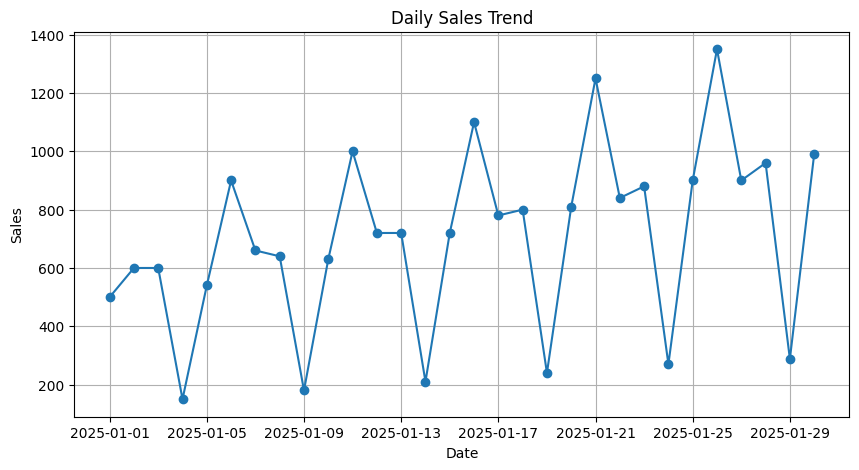

In [8]:
daily_sales = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_sales.index,
         daily_sales.values,
         marker='o')

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

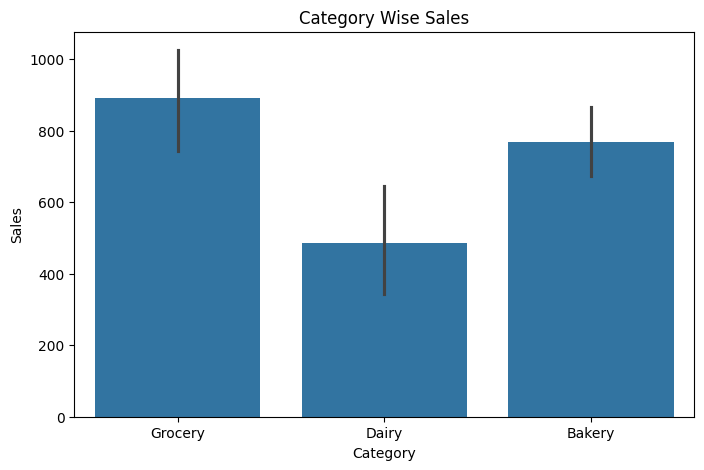

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Category',
    y='Sales',
    data=df
)

plt.title("Category Wise Sales")
plt.show()

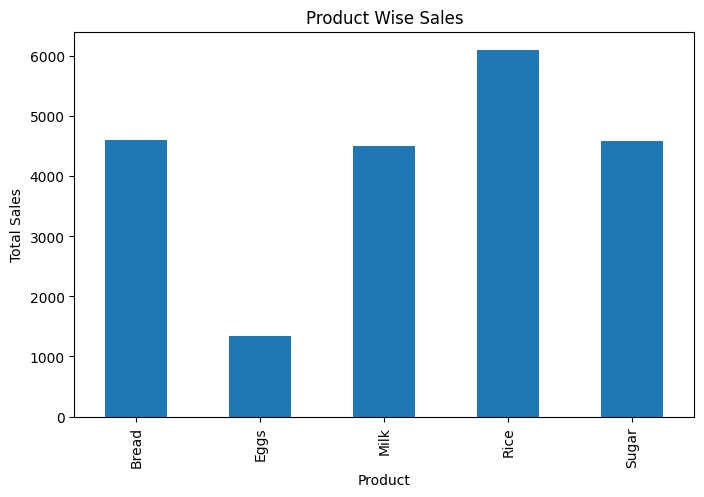

In [10]:
product_sales = df.groupby('Product')['Sales'].sum()

plt.figure(figsize=(8,5))

product_sales.plot(
    kind='bar'
)

plt.title("Product Wise Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.show()

In [11]:
X = df[['Quantity','Price']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[25.42,26.59]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Quantity','Price']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-803.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [12]:
y_pred = model.predict(X_test)

print("\nACTUAL SALES")
print(y_test.values)

print("\nPREDICTED SALES")
print(y_pred)



ACTUAL SALES
[ 960 1100  270  800  180  630]

PREDICTED SALES
[ 870.35924237 1085.44389901  500.02011564  768.68355057  118.73627141
  749.13126415]


In [13]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("\nMODEL PERFORMANCE")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 SCORE :", r2)


MODEL PERFORMANCE
MAE : 90.98806940472956
MSE : 13347.136941133924
RMSE : 115.52980975113707
R2 SCORE : 0.8833518814622205


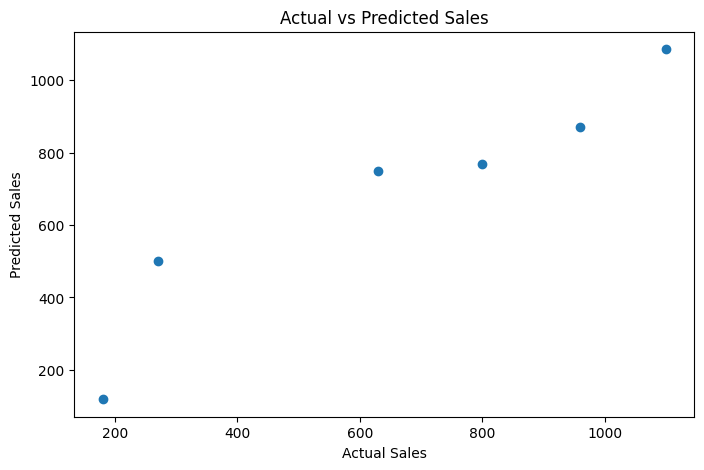

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales"
)

plt.show()